In [1]:
!pip install nltk


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
pip install -r requirements.txt

   ---------------------------------------- 0.0/306.1 kB ? eta -:--:--
   - -------------------------------------- 10.2/306.1 kB ? eta -:--:--
   ----- --------------------------------- 41.0/306.1 kB 653.6 kB/s eta 0:00:01
   --------- ----------------------------- 71.7/306.1 kB 787.7 kB/s eta 0:00:01
   ------------------- ------------------ 153.6/306.1 kB 919.0 kB/s eta 0:00:01
   ------------------------ ------------- 194.6/306.1 kB 908.0 kB/s eta 0:00:01
   --------------------------- ---------- 225.3/306.1 kB 860.2 kB/s eta 0:00:01
   ----------------------------- -------- 235.5/306.1 kB 850.1 kB/s eta 0:00:01
   ------------------------------- ------ 256.0/306.1 kB 749.3 kB/s eta 0:00:01
   ---------------------------------- --- 276.5/306.1 kB 774.0 kB/s eta 0:00:01
   -------------------------------------- 306.1/306.1 kB 701.0 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: e:\Personal Projects\project ongoing\ds_env\Scripts\python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
import string
import seaborn as sns
from nltk.stem.porter import PorterStemmer
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import StackingClassifier
import pickle
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score,precision_score

In [7]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User1\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [8]:
df = pd.read_csv('fake reviews dataset.csv')

df.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


In [9]:
df.drop(columns = {'category'}, inplace = True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   rating  40432 non-null  float64
 1   label   40432 non-null  object 
 2   text_   40432 non-null  object 
dtypes: float64(1), object(2)
memory usage: 947.8+ KB


In [11]:
df.rename(columns = {'text_': 'text'}, inplace = True)

In [12]:
df.head()

,rating,label,text
0,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,5.0,CG,"love it, a great upgrade from the original. I..."
2,5.0,CG,This pillow saved my back. I love the look and...
3,1.0,CG,"Missing information on how to use it, but it i..."
4,5.0,CG,Very nice set. Good quality. We have had the s...


In [13]:
def encode_label(df):
    labels = {
        'CG': 0,
        'OR': 1
    }

    df['target'] = df['label'].map(labels)

    return df

In [14]:
df = encode_label(df)
df['target'] = df['target'].fillna(0).replace([np.inf, -np.inf], 0)
df['target'] = df['target'].astype(int)
df.head()

,rating,label,text,target
0,5.0,CG,"Love this! Well made, sturdy, and very comfor...",0
1,5.0,CG,"love it, a great upgrade from the original. I...",0
2,5.0,CG,This pillow saved my back. I love the look and...,0
3,1.0,CG,"Missing information on how to use it, but it i...",0
4,5.0,CG,Very nice set. Good quality. We have had the s...,0


In [15]:
df.drop(columns = {'rating', 'label'}, inplace = True)

In [16]:
df = df.sample(frac=1).reset_index(drop=True)

df.sample(10)

,text,target
19083,"The full story finally told, and it kept me en...",0
39848,The topper fit perfectly and is very comfortab...,1
33458,Are you kidding? My son has been wearing thes...,0
22301,"Does not have the ""soft"" feel of a leather cas...",1
26790,I bought a Hoover Max vacuum for my son's scho...,0
3707,This is a touching story told through a child'...,1
8482,Such fun for little girls. Pieces went togethe...,1
16452,They worked out great holding up to the rigors...,0
26637,My husband has really wide feet and the wide w...,0
25590,"Super cute sunglasses, very well made. They do...",1


In [17]:
df.isnull().sum()

text      0
target    0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(20)

In [19]:
df.drop_duplicates(inplace = True)

In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df['target'].value_counts()

target
1    20215
0    20197
Name: count, dtype: int64

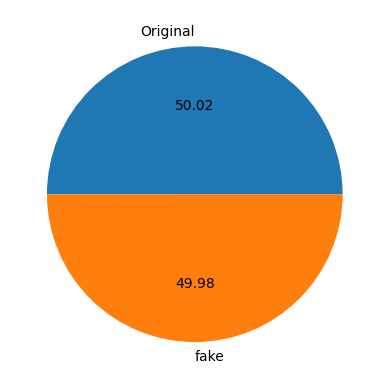

In [22]:
plt.pie(df['target'].value_counts(), labels=['Original', 'fake'],autopct="%0.2f")
plt.show()

In [23]:
df['num_characters'] = df['text'].apply(len)
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [24]:
df.head()

,text,target,num_characters,num_words,num_sentences
0,"After purchasing the&nbsp;<a data-hook=""produc...",1,905,173,9
1,Definitely convenient than carrying my iPad. T...,0,442,99,7
2,Great movie about WWII in a fun and entertaini...,0,1053,237,19
3,I downloaded this book a month ago and I canno...,1,181,39,2
4,Both of my dogs (full grown) love the taste. I...,0,193,47,5


In [25]:
df.describe()

,target,num_characters,num_words,num_sentences
count,40412.000000,40412.000000,40412.000000,40412.000000
mean,0.500223,351.365337,76.691131,5.277071
std,0.500006,369.871842,79.242859,4.915033
min,0.000000,24.000000,2.000000,1.000000
25%,0.000000,107.000000,24.000000,2.000000
50%,1.000000,198.000000,44.000000,3.000000
75%,1.000000,439.000000,96.000000,6.000000
max,1.000000,2827.000000,510.000000,133.000000


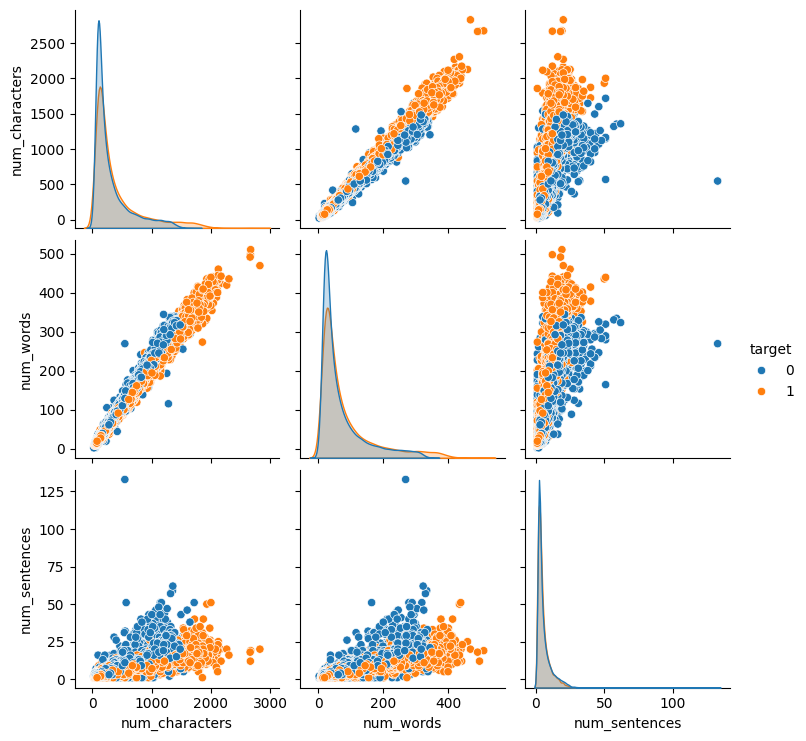

In [26]:
sns.pairplot(df,hue='target')

<Axes: >

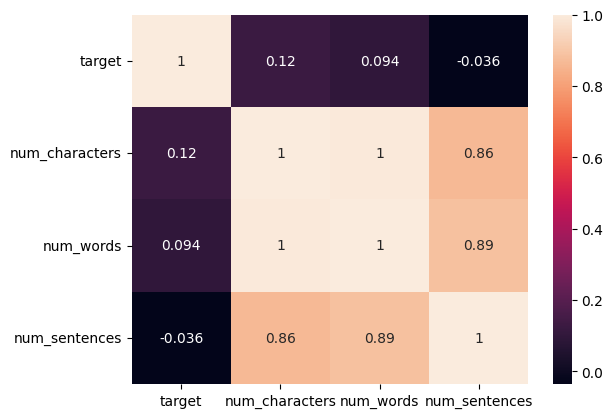

In [27]:
df_numeric = df.select_dtypes(include = 'number')
sns.heatmap(df_numeric.corr(),annot=True)

In [28]:
ps = PorterStemmer()

In [29]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))


    return " ".join(y)

In [30]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User1\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [31]:
transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [32]:
df['transformed_text'] = df['text'].apply(transform_text)

In [33]:
df.head()

,text,target,num_characters,num_words,num_sentences,transformed_text
0,"After purchasing the&nbsp;<a data-hook=""produc...",1,905,173,9,purchas nbsp iain sinclair cardsharp 2 black c...
1,Definitely convenient than carrying my iPad. T...,0,442,99,7,definit conveni carri ipad problem kind hard f...
2,Great movie about WWII in a fun and entertaini...,0,1053,237,19,great movi wwii fun entertain way watch love m...
3,I downloaded this book a month ago and I canno...,1,181,39,2,download book month ago believ wait today read...
4,Both of my dogs (full grown) love the taste. I...,0,193,47,5,dog full grown love tast keep next coupl month...


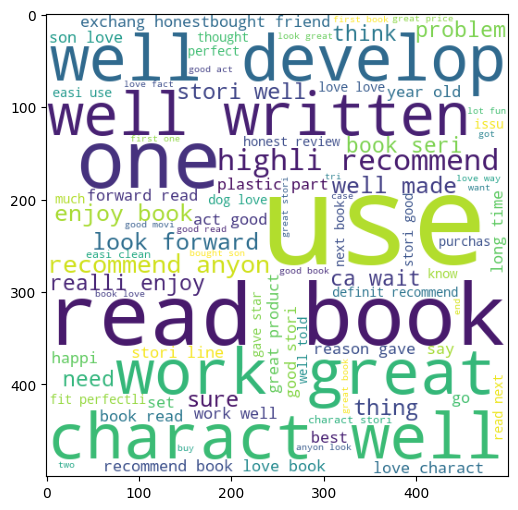

In [34]:
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')
fake_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(fake_wc)

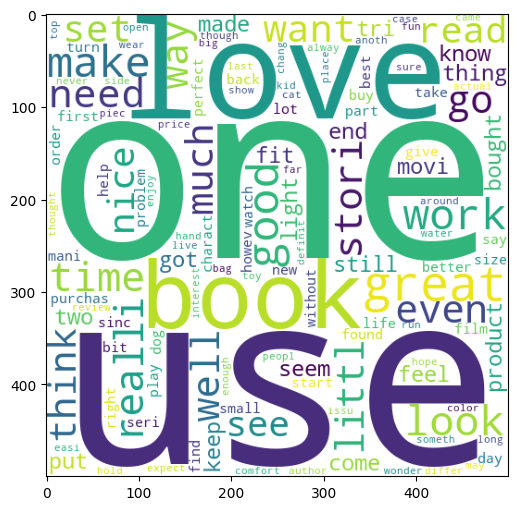

In [35]:
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')
original_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(original_wc)

In [36]:
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['transformed_text']).toarray()
y = df['target'].values

In [37]:
print(X.shape)
print(y.shape)

(40412, 3000)
(40412,)


In [38]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=32)

In [39]:
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [40]:
clfs = {
    'KN' : knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'xgb':xgb
}

In [41]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')

    return accuracy,precision

In [42]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

e:\Personal Projects\project ongoing\ds_env\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "e:\Personal Projects\project ongoing\ds_env\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\Personal Projects\project ongoing\ds_env\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\User1\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*p

In [43]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [44]:
performance_df.reset_index(drop = True)

,Algorithm,Accuracy,Precision
0,LR,0.855252,0.855254
1,NB,0.839540,0.840135
2,RF,0.831498,0.833001
3,xgb,0.816157,0.817766
4,AdaBoost,0.673636,0.684477
5,DT,0.590622,0.633951
6,KN,0.509341,0.543814


In [45]:
mnb = MultinomialNB()
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)

In [46]:
voting = VotingClassifier(estimators=[('LR', lrc), ('nb', mnb), ('RF', rfc)],voting='soft')

In [47]:
voting.fit(X_train,y_train)

e:\Personal Projects\project ongoing\ds_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
e:\Personal Projects\project ongoing\ds_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('LR', ...), ('nb', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [48]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.8656439440801682
Precision 0.871494135645079


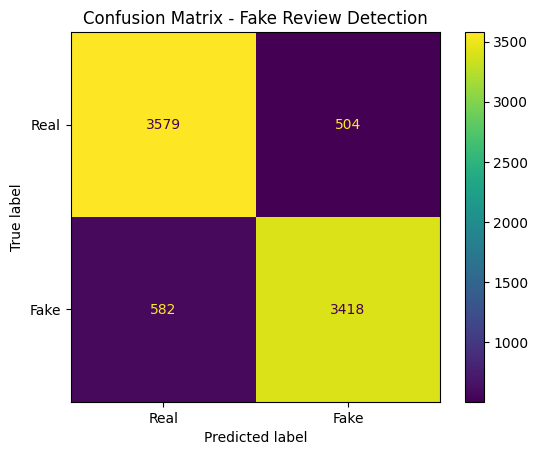

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot it

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Real", "Fake"])
disp.plot()

plt.title("Confusion Matrix - Fake Review Detection")
plt.show()

In [50]:
estimators = [('LR', lrc), ('nb', mnb), ('RF', rfc)]
final_estimator = RandomForestClassifier(n_estimators=50, random_state=2)

In [51]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [52]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

e:\Personal Projects\project ongoing\ds_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
e:\Personal Projects\project ongoing\ds_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
e:\Personal Projects\project ongoing\ds_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penal

Accuracy 0.8594581219844117
Precision 0.8572854291417166


In [53]:
pickle.dump(tfidf,open('vectorizer.pkl','wb'))


In [54]:
pickle.dump(clf, open('model.pkl','wb'))

In [55]:
import time

models_to_eval = {
    'Logistic Regression': lrc,
    'Multinomial NB':      mnb,
    'Random Forest':       rfc,
    'XGBoost':             xgb,
    'Voting Classifier':   voting,
    'Stacking Classifier': clf,
}

timing_results = {}

for name, model in models_to_eval.items():
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    
    start = time.time()
    preds = model.predict(X_test)
    infer_time = time.time() - start
    
    timing_results[name] = {
        'train_time_sec': round(train_time, 3),
        'infer_time_sec': round(infer_time, 4),
        'accuracy':       round(accuracy_score(y_test, preds), 4),
        'precision':      round(precision_score(y_test, preds), 4),
    }
    print(f"{name}: train={train_time:.2f}s, infer={infer_time:.4f}s")

import json
print(json.dumps(timing_results, indent=2))

e:\Personal Projects\project ongoing\ds_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
e:\Personal Projects\project ongoing\ds_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Logistic Regression: train=2.61s, infer=0.4754s
Multinomial NB: train=0.41s, infer=0.0563s
Random Forest: train=46.18s, infer=0.6080s
XGBoost: train=25.08s, infer=0.1764s


e:\Personal Projects\project ongoing\ds_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
e:\Personal Projects\project ongoing\ds_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Voting Classifier: train=81.79s, infer=1.0833s


e:\Personal Projects\project ongoing\ds_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
e:\Personal Projects\project ongoing\ds_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
e:\Personal Projects\project ongoing\ds_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penal

Stacking Classifier: train=493.67s, infer=1.1554s
{
  "Logistic Regression": {
    "train_time_sec": 2.61,
    "infer_time_sec": 0.4754,
    "accuracy": 0.8553,
    "precision": 0.8534
  },
  "Multinomial NB": {
    "train_time_sec": 0.411,
    "infer_time_sec": 0.0563,
    "accuracy": 0.8395,
    "precision": 0.8537
  },
  "Random Forest": {
    "train_time_sec": 46.179,
    "infer_time_sec": 0.608,
    "accuracy": 0.8315,
    "precision": 0.8548
  },
  "XGBoost": {
    "train_time_sec": 25.083,
    "infer_time_sec": 0.1764,
    "accuracy": 0.8162,
    "precision": 0.794
  },
  "Voting Classifier": {
    "train_time_sec": 81.785,
    "infer_time_sec": 1.0833,
    "accuracy": 0.8656,
    "precision": 0.8715
  },
  "Stacking Classifier": {
    "train_time_sec": 493.669,
    "infer_time_sec": 1.1554,
    "accuracy": 0.857,
    "precision": 0.8567
  }
}
